<a href="https://colab.research.google.com/github/Asaf21S/constrained-flow-matching/blob/main/notebooks/constraint_distillation/constrained_gaussian_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
!pip install torchcfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.2 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher, ExactOptimalTransportConditionalFlowMatcher
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import math

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Dataset

In [4]:
RNG = np.random.default_rng()

In [29]:
def get_1d_gaussian_data(peaks: list[tuple[float, float]], n_samples: int, rng=RNG):
    means = np.array([p[0] for p in peaks])
    stds = np.array([p[1] for p in peaks])
    weights = np.full(len(peaks), 1.0 / len(peaks))

    # Pick which peak each sample belongs to
    choices = rng.choice(len(peaks), p=weights, size=n_samples)

    # Generate standard normal samples (mean=0, std=1)
    base_samples = rng.standard_normal(size=n_samples)

    # Scale and shift the base samples
    mixture_samples = (base_samples * stds[choices]) + means[choices]

    return torch.from_numpy(mixture_samples).float()

In [51]:
real_data = get_1d_gaussian_data(peaks=[(0, 1), (4, 1), (-8, 4)], n_samples=100000)

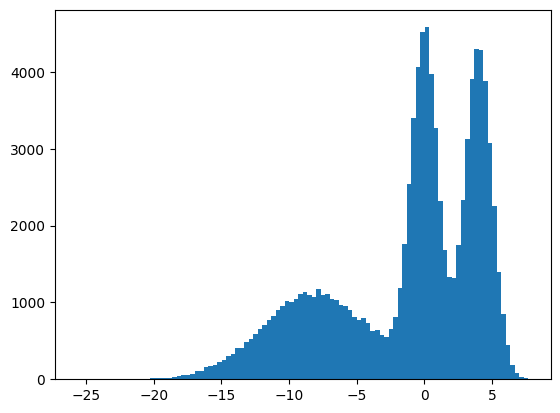

In [54]:
# plot data:
plt.hist(real_data, bins=100)
plt.show()

# Model definition

In [28]:
class FlowMatchingMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # Input is 2D: [position x_t, time t]
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 1) # Output is 1D: velocity
        )

    def forward(self, x, t):
        # Concatenate x and t to feed into the MLP
        # x shape: (batch_size, 1), t shape: (batch_size, 1)
        input_features = torch.cat([x, t], dim=-1)
        return self.net(input_features)

# Train loop

In [39]:
# Settings
peaks=[(0, 1), (4, 1), (-8, 4)]
model = FlowMatchingMLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=0.0)
iterations = 10000
batch_size = 256

loss_list = []

In [40]:
for step in tqdm(range(iterations)):
    optimizer.zero_grad()
    x1 = get_1d_gaussian_data(peaks, n_samples=batch_size).to(device)  # real data
    x1 = x1.view(-1, 1)
    x0 = torch.randn_like(x1).to(device)  # noise

    # compute loss
    t, xt, real_vt = FM.sample_location_and_conditional_flow(x0, x1)
    t = t.view(-1, 1)
    pred_vt = model(xt, t)
    loss = torch.mean((pred_vt - real_vt) ** 2)
    loss_list.append(loss.item())
    if step % (iterations / 10) == 0:
        print(np.mean(loss_list[step - int(iterations/10):step+1]))

    loss.backward()
    optimizer.step()

  0%|          | 0/10000 [00:00<?, ?it/s]

22.373184204101562
1.1378973598901805
0.165152855362598
0.15052247585749234
0.14124734090319224
0.13473701783335887
0.13275956947144332
0.12863549150593512
0.12673650552461913
0.12505962499617398


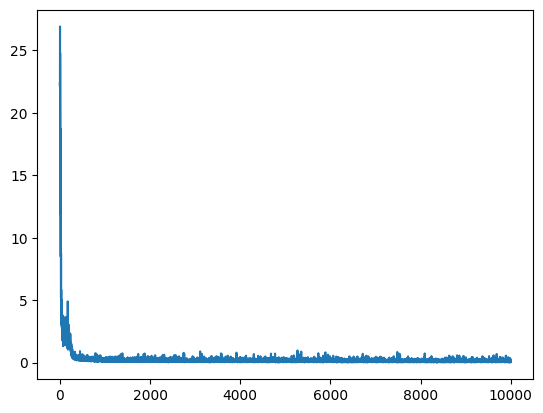

In [41]:
plt.plot(loss_list)
plt.show()

# Standard Generation

In [48]:
def sample_trajectory(model, n_samples, steps=100):
    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    traj = [x.cpu()]
    model.eval()
    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.full((n_samples, 1), t, device=device)
            v = model(x, t_batch)
            x = x + v * dt
            traj.append(x.cpu())

    return torch.stack(traj).numpy()  # Final shape: [steps + 1, n_samples, 2]

In [49]:
sampled_data = sample_trajectory(model, n_samples=10000)

In [50]:
def visualize_fm(sampled_data, title="1D Flow Matching Results", alpha=0.5, true_data=None):
    """
    Visualizes Flow Matching trajectories and final distributions for 1D data.

    Args:
        sampled_data: numpy array of shape [steps, n_samples, 1] or [steps, n_samples]
        title: Title for the final distribution plot
        alpha: Transparency for the histogram
        true_data: Optional numpy array of real target data for comparison
    """
    # Safety check: If shape is [steps, n_samples, 1], squeeze it to [steps, n_samples]
    # Matplotlib prefers 1D or 2D arrays for plotting, not 3D.
    if sampled_data.ndim == 3 and sampled_data.shape[-1] == 1:
        sampled_data = sampled_data.squeeze(-1)

    start_points = sampled_data[0]  # t=0 (Noise)
    end_points = sampled_data[-1]   # t=1 (Generated Data)
    n_steps, n_samples = sampled_data.shape

    # Limit trajectory drawing to 100 lines to keep the plot readable
    n_plot = min(100, n_samples)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ==========================================
    # 1. Flow Plot: Time (t) vs. Position (x)
    # ==========================================
    axes[0].set_title("1D Trajectories Over Time")
    t_values = np.linspace(0, 1, n_steps)

    # Matplotlib Trick: Plotting a 2D array draws a line for every column automatically!
    axes[0].plot(t_values, sampled_data[:, :n_plot], color='black', alpha=0.1)

    # Mark start and end points
    axes[0].scatter(np.zeros(n_plot), start_points[:n_plot],
                    c='red', s=15, label='Start (Noise, t=0)', zorder=3)
    axes[0].scatter(np.ones(n_plot), end_points[:n_plot],
                    c='blue', s=15, label='End (Data, t=1)', zorder=3)

    axes[0].set_xlabel("Time (t)")
    axes[0].set_ylabel("Position (x)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ==========================================
    # 2. Final Distribution: Histogram
    # ==========================================
    axes[1].set_title(title)

    # If you provided the real GMM dataset, plot it in the background
    if true_data is not None:
        # Squeeze true_data just in case it's shape [batch, 1]
        if true_data.ndim == 2 and true_data.shape[-1] == 1:
            true_data = true_data.squeeze(-1)

        axes[1].hist(true_data, bins=50, density=True, color='magenta',
                     alpha=0.3, label="Target (True Data)")

    axes[1].hist(end_points, bins=50, density=True, color='blue',
                 alpha=alpha, label="Generated Data")

    axes[1].set_xlabel("Position (x)")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

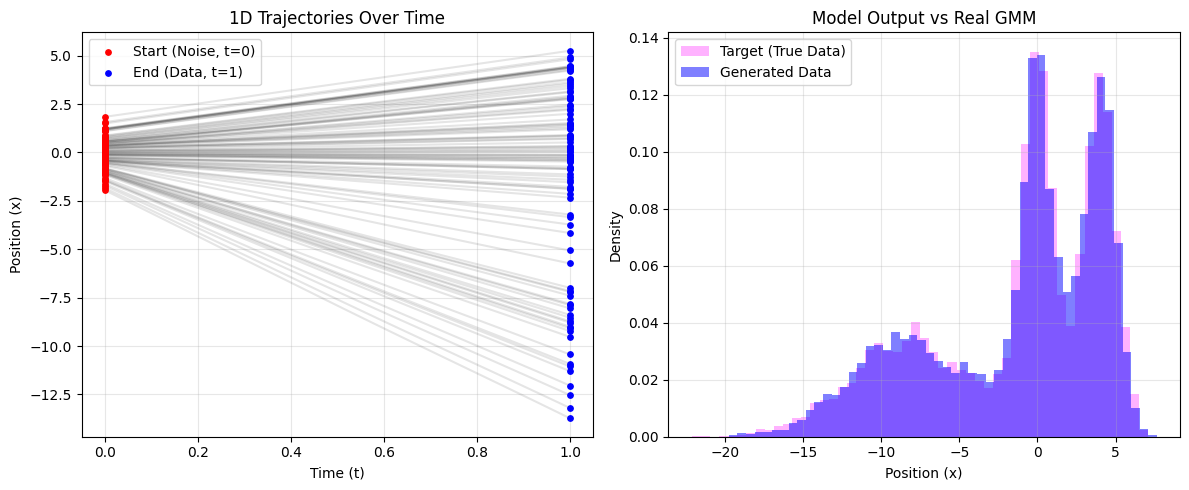

In [53]:
visualize_fm(
    sampled_data=sampled_data,
    true_data=real_data[:10000],
    title="Model Output vs Real GMM"
)

# Data sampler - ECI

In [ ]:
def sample_mnist_eci(model, n_samples, constraint_fn, steps=100, correction_loops=1):
    model.eval()
    x = torch.randn(n_samples, 1, 32, 32).to(device)
    x0 = x.clone()
    dt = 1.0 / steps

    traj = [x[0].clone().cpu()]
    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.ones(n_samples).to(device) * t
            for m in range(correction_loops):  # applying the eci projections m times every step
                # Extrapolation
                v = model(t_batch, x)
                x1_pred = x + (1 - t) * v

                # Correction
                x1_corrected = constraint_fn(x1_pred)

                # Interpolation
                x_new = (1 - t) * x0 + t * x1_corrected
                if m < correction_loops - 1:
                    x = x_new

            next_t = t + dt
            x = (1 - next_t) * x0 + next_t * x1_corrected
            traj.append(x[0].clone().cpu())

    # [-1, 1] -> [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x.cpu(), torch.stack(traj).numpy()  # traj size [steps, 1, 32, 32]

### Black Hole Constraint

In [ ]:
def center_black_hole_constraint(x1_pred):
    """
    Forces the center 6x6 pixels to be Black (-1).
    Image size: 32x32.
    Center indices: 13 to 19 (6 pixels).
    """
    x1_fixed = x1_pred.clone()
    x1_fixed[:, :, 13:19, 13:19] = -1.0

    return x1_fixed

In [ ]:
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=center_black_hole_constraint, correction_loops=1)

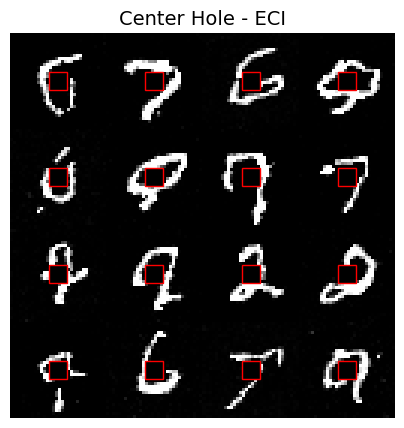

In [ ]:
show_mnist_grid(sampled_data_eci, "Center Hole - ECI", add_middle_rect=True)

### Total Ink Constraint

In [ ]:
def total_ink_constraint(x1_pred, target_ink=100.0):
    """
    Forces the total 'ink' (sum of pixel intensities) to be exactly K.
    1. Converts [-1, 1] to [0, 1] space.
    2. Scales the intensities to match the target sum.
    3. Converts back to [-1, 1].
    """
    x1_fixed = x1_pred.clone()

    ink_values = (x1_fixed + 1) / 2
    current_ink = ink_values.sum(dim=(1, 2, 3))  # size [batch]
    current_ink = torch.clamp(current_ink, min=1e-5)

    scale_factor = (target_ink / current_ink).view(-1, 1, 1, 1)
    new_ink = ink_values * scale_factor
    x1_fixed = new_ink * 2 - 1
    return torch.clamp(x1_fixed, -1, 1)

In [ ]:
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=lambda x: total_ink_constraint(x, target_ink=60.0), correction_loops=1)

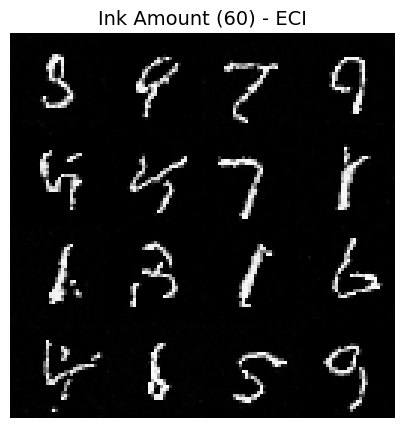

In [ ]:
show_mnist_grid(sampled_data_eci, "Ink Amount (60) - ECI")

In [ ]:
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=lambda x: total_ink_constraint(x, target_ink=150.0), correction_loops=1)

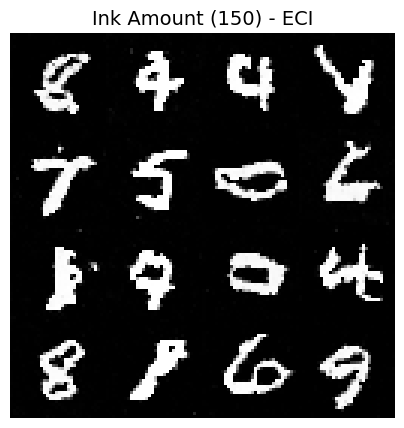

In [ ]:
show_mnist_grid(sampled_data_eci, "Ink Amount (150) - ECI")

### Symmetry Constraint

In [ ]:
def symmetry_constraint(x1_pred):
    """
    Forces Vertical Symmetry (Left side mirrors Right side).
    Formula: x = (x + flip_lr(x)) / 2
    """
    x_flipped = torch.flip(x1_pred, dims=[-1])
    x_fixed = (x1_pred + x_flipped) / 2.0
    return x_fixed

In [ ]:
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=symmetry_constraint, correction_loops=1)

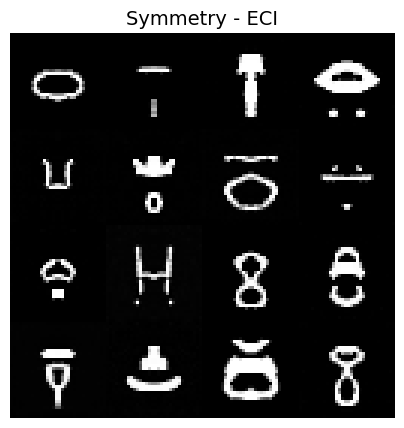

In [ ]:
show_mnist_grid(sampled_data_eci, "Symmetry - ECI")

### Specific Digit Constraint

In [ ]:
def get_digit_subspace(target_digit, n_components=10, device='cuda'):
    """
    Calculates the PCA basis for a specific digit using the exact same
    preprocessing as the training loader.
    """
    print(f"--- Computing Subspace for Digit {target_digit} ---")

    transform = transforms.Compose([
        transforms.Pad(2),              # 28x28 -> 32x32
        transforms.ToTensor(),          # [0, 255] -> [0, 1]
        transforms.Normalize((0.5,), (0.5,)) # [0, 1] -> [-1, 1]
    ])

    dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

    idx = (dataset.targets == target_digit).nonzero(as_tuple=True)[0]
    print(f"Found {len(idx)} examples of digit {target_digit}")

    subset = torch.utils.data.Subset(dataset, idx)
    loader = torch.utils.data.DataLoader(subset, batch_size=1000, shuffle=False)

    all_images = []
    for x, _ in loader:
        all_images.append(x)

    data_tensor = torch.cat(all_images, dim=0).to(device)  # [N, 1, 32, 32]

    B, C, H, W = data_tensor.shape
    flat_data = data_tensor.view(B, -1)  # [N, 1024]

    # Perform PCA (SVD)
    mean_vec = torch.mean(flat_data, dim=0)

    centered_data = flat_data - mean_vec

    U, S, V = torch.pca_lowrank(centered_data, q=n_components)

    # V is [1024, n_components]
    basis_vectors = V.T

    print(f"PCA Computed. Basis shape: {basis_vectors.shape}")
    return mean_vec, basis_vectors

In [ ]:
def visualize_subspace(mean, basis):
    # [-1, 1] -> [0, 1]
    def to_img(t):
        return (t.view(32, 32).cpu() + 1) / 2

    plt.figure(figsize=(10, 4))

    # Plot Mean
    plt.subplot(1, 6, 1)
    plt.title("Mean digit")
    plt.imshow(to_img(mean), cmap='gray')
    plt.axis('off')

    # Plot top 5 Variations
    for i in range(5):
        plt.subplot(1, 6, i+2)
        plt.title(f"Comp {i+1}")
        # Components are directions
        plt.imshow(basis[i].view(32, 32).cpu(), cmap='bwr') # Blue-White-Red colormap
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def pca_constraint_fn(x1_pred, mean_digit, basis_vectors):
    """
    Projector: Forces x1 to lie on the linear subspace of the target digit.
    Math: x_proj = Mean + V * V^T * (x - Mean)
    """
    B, C, H, W = x1_pred.shape

    x_flat = x1_pred.view(B, -1)  # [Batch, 1024]
    x_centered = x_flat - mean_digit

    scores = torch.matmul(x_centered, basis_vectors.T)
    x_recon = torch.matmul(scores, basis_vectors)
    x_out = x_recon + mean_digit

    return x_out.view(B, C, H, W)

In [ ]:
n_components = 20
mean_vec_list = []
basis_vectors_list = []
for digit in range(10):
    mean_vec, basis_vectors = get_digit_subspace(target_digit=digit, n_components=n_components, device=device)
    mean_vec_list.append(mean_vec)
    basis_vectors_list.append(basis_vectors)

--- Computing Subspace for Digit 0 ---
Found 5923 examples of digit 0
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 1 ---
Found 6742 examples of digit 1
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 2 ---
Found 5958 examples of digit 2
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 3 ---
Found 6131 examples of digit 3
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 4 ---
Found 5842 examples of digit 4
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 5 ---
Found 5421 examples of digit 5
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 6 ---
Found 5918 examples of digit 6
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 7 ---
Found 6265 examples of digit 7
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 8 ---
F

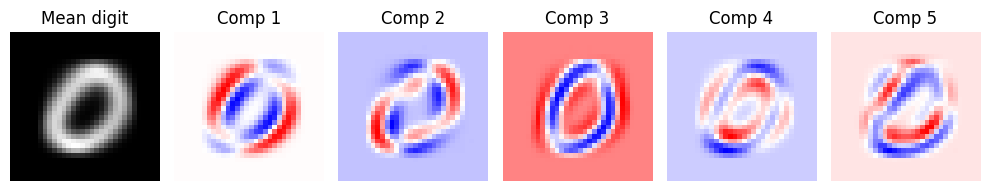

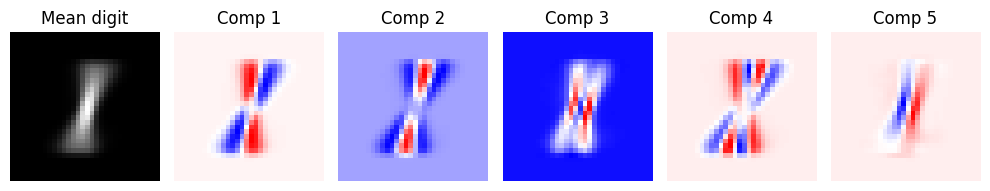

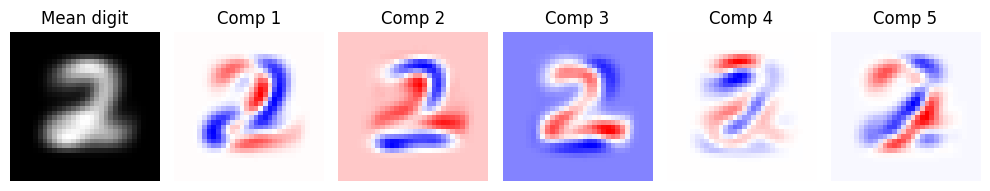

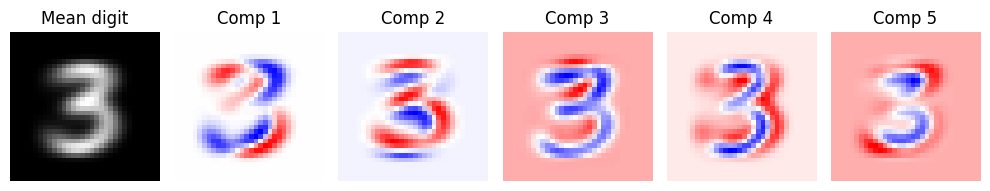

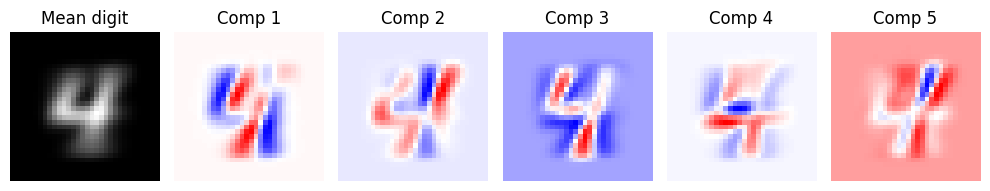

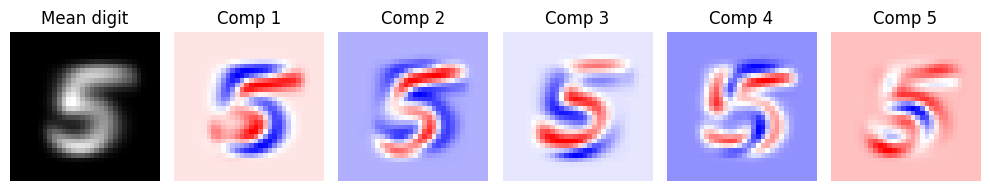

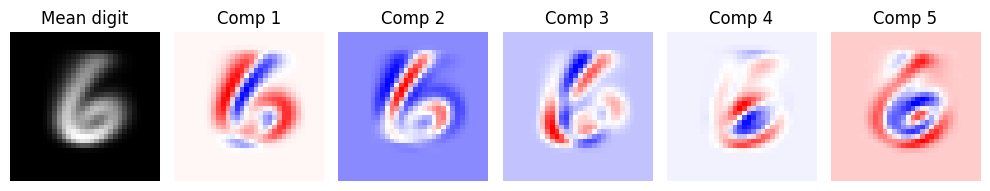

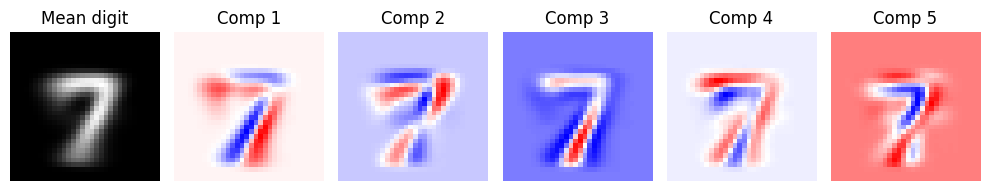

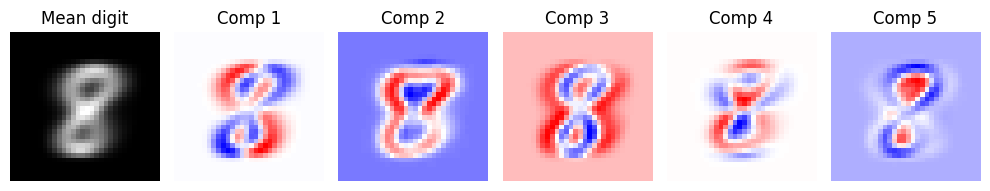

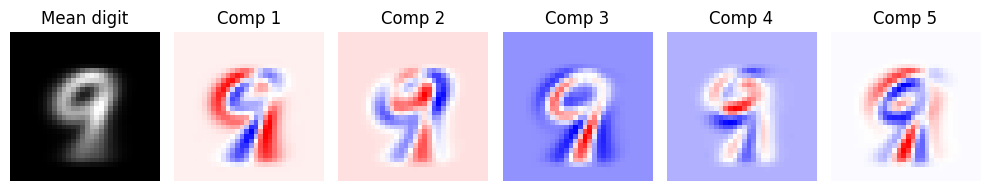

In [ ]:
for digit in range(10):
    mean_vec = mean_vec_list[digit]
    basis_vectors = basis_vectors_list[digit]
    visualize_subspace(mean_vec, basis_vectors)

In [ ]:
digit = 3
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=lambda x: pca_constraint_fn(x, mean_vec_list[digit], basis_vectors_list[digit]), correction_loops=1)

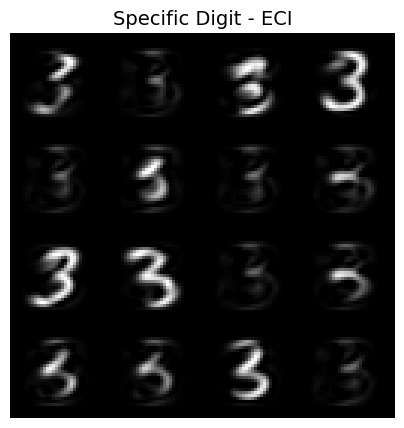

In [ ]:
show_mnist_grid(sampled_data_eci, "Specific Digit - ECI")

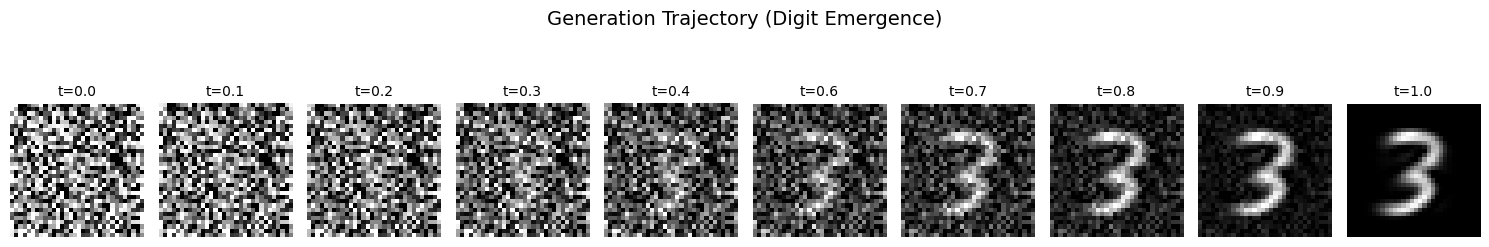

In [ ]:
visualize_trajectory_snapshots(traj_eci)

In [ ]:
sampled_data_eci_list = []
for digit in range(10):
    sampled_data_eci_digit, _ = sample_mnist_eci(model, n_samples=10, constraint_fn=lambda x: pca_constraint_fn(x, mean_vec_list[digit], basis_vectors_list[digit]), correction_loops=1)
    sampled_data_eci_list.append(sampled_data_eci_digit)

In [ ]:
def show_all_digits_grid(dampled_data_list, title: str):
    all_samples = torch.cat(dampled_data_list, dim=0).detach().cpu()

    grid_img = torchvision.utils.make_grid(all_samples, nrow=10, padding=0)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(title, fontsize=20, pad=20)
    ax.axis('off')
    ax.imshow(grid_img.permute(1, 2, 0).numpy())

    # Add the row labels using global coordinates
    for digit_idx in range(10):
        y_center = digit_idx * 32 + 16
        ax.text(-10, y_center, f"Digit {digit_idx}", fontsize=14, ha='right', va='center', fontweight='bold')

    plt.show()

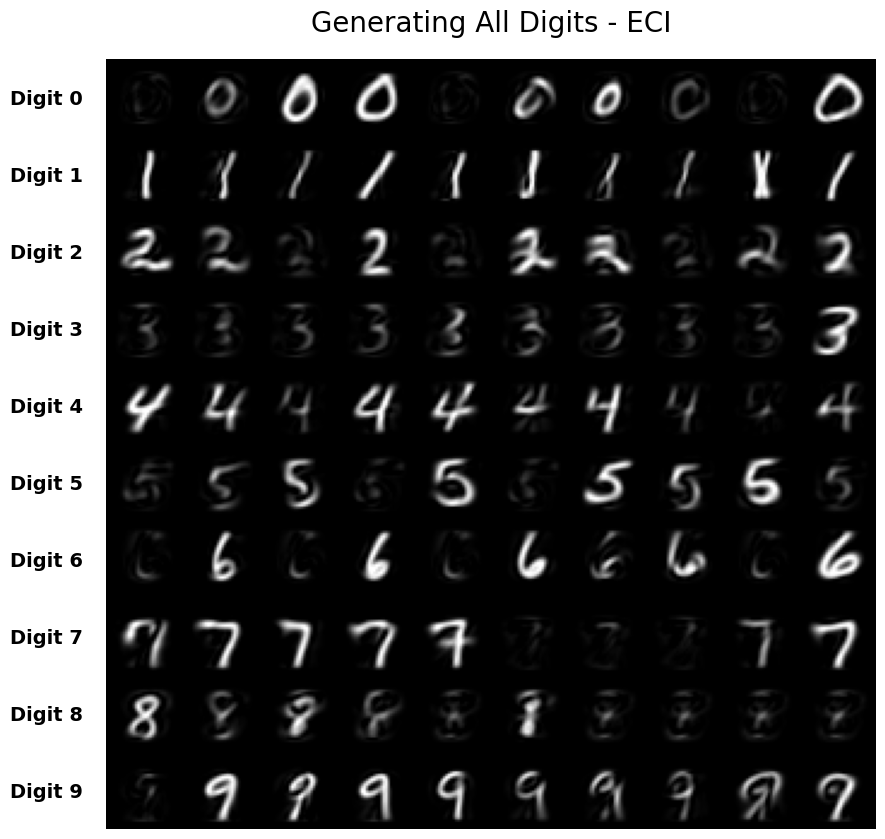

In [ ]:
show_all_digits_grid(sampled_data_eci_list, "Generating All Digits - ECI")

# HardFlow

In [ ]:
def sample_mnist_hardflow(model, n_samples, loss_fn, steps=100, guidance_scale=5.0):
    """
    HardFlow-style sampling for high-dimensional image data (MNIST).
    """
    model.eval()

    x = torch.randn(n_samples, 1, 32, 32).to(device)
    dt = 1.0 / steps

    traj = [x[0].clone().cpu()]

    for i in range(steps):
        t_scalar = i * dt
        t_batch = torch.ones(n_samples).to(device) * t_scalar

        x = x.detach().requires_grad_(True)

        v = model(t_batch, x)

        # predict the destination
        x1_hat = x + (1 - t_scalar) * v

        # calculate the constraint loss on the predicted destination
        loss = loss_fn(x1_hat).sum()

        # calculate the gradient w.r.t x_t
        grad = torch.autograd.grad(loss, x)[0]

        # apply guidance - subtract the gradient from the velocity to pull it towards lower loss
        v_guided = v - guidance_scale * grad

        x = x.detach() + v_guided.detach() * dt

        traj.append(x[0].clone().cpu())

    x_final = (x.clamp(-1, 1) + 1) / 2

    return x_final.cpu(), torch.stack(traj).numpy()

### Black Hole Constraint

In [ ]:
def center_black_hole_loss(x1_hat):
    """
    Penalizes pixels in the center 6x6 region that are not Black (-1).
    Image size: 32x32.
    Center indices: 13 to 19 (6 pixels).
    """
    center_region = x1_hat[:, :, 13:19, 13:19]
    loss = (center_region + 1.0) ** 2
    return loss

In [ ]:
sampled_data_hardflow, traj_hardflow = sample_mnist_hardflow(model, n_samples=16, loss_fn=center_black_hole_loss, guidance_scale=20.0)

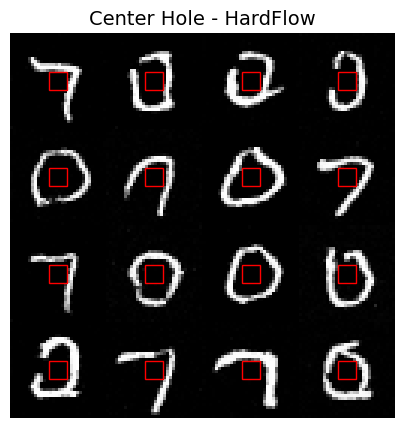

In [ ]:
show_mnist_grid(sampled_data_hardflow, "Center Hole - HardFlow", add_middle_rect=True)

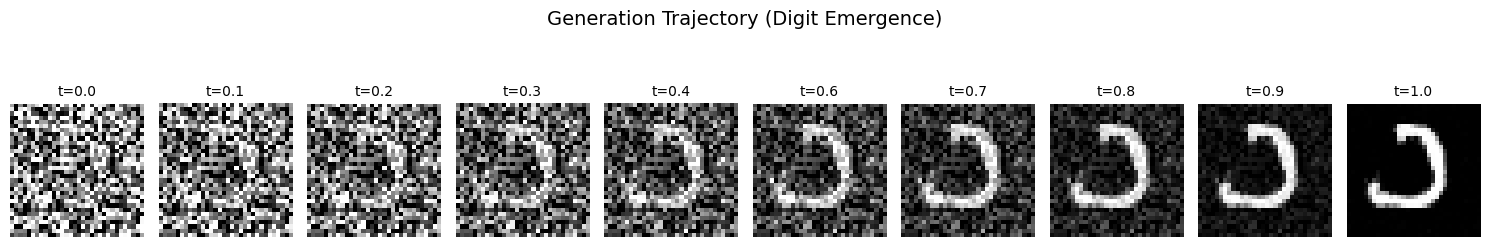

In [ ]:
visualize_trajectory_snapshots(traj_hardflow)

### Total Ink Constraint

In [ ]:
def total_ink_loss(x1_hat, target_ink=60.0):
    """
    Penalizes images whose total ink (sum of pixel intensities in [0, 1] space)
    deviates from the target_ink.
    """
    ink_values = (x1_hat + 1) / 2
    current_ink = ink_values.sum(dim=(1, 2, 3))
    loss = (current_ink - target_ink) ** 2
    return loss

In [ ]:
sampled_data_hf, traj_hf = sample_mnist_hardflow(model, n_samples=16, loss_fn=lambda x: total_ink_loss(x, target_ink=60.0), guidance_scale=0.01)

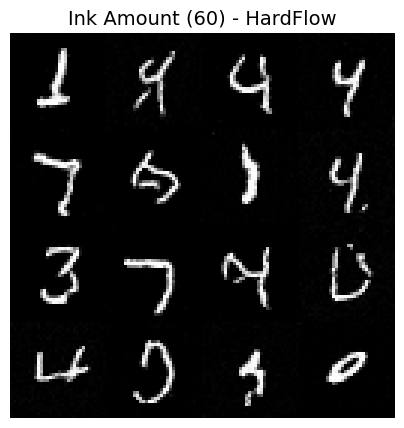

In [ ]:
show_mnist_grid(sampled_data_hf, "Ink Amount (60) - HardFlow")

In [ ]:
sampled_data_hf, traj_hf = sample_mnist_hardflow(model, n_samples=16, loss_fn=lambda x: total_ink_loss(x, target_ink=150.0), guidance_scale=0.01)

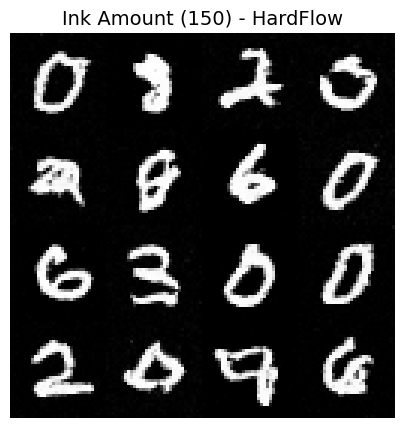

In [ ]:
show_mnist_grid(sampled_data_hf, "Ink Amount (150) - HardFlow")

### Symmetry Constraint

In [ ]:
def symmetry_loss(x1_hat):
    """
    Penalizes images that are not horizontally symmetric.
    Calculates the squared difference between the image and its flipped version.
    """
    x1_flipped = torch.flip(x1_hat, dims=[-1])
    loss = torch.abs(x1_hat - x1_flipped)
    return loss

In [ ]:
sampled_data_hf, traj_hf = sample_mnist_hardflow(model, n_samples=16, loss_fn=symmetry_loss, guidance_scale=10.0)

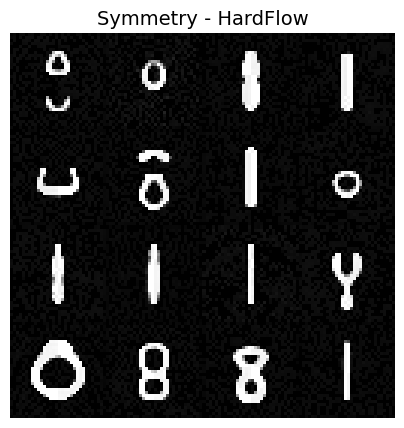

In [ ]:
show_mnist_grid(sampled_data_hf, "Symmetry - HardFlow")

### Specific Digit Constraint

In [ ]:
def pca_subspace_loss(x1_hat, mean_digit, basis_vectors):
    """
    Penalizes the orthogonal distance between the predicted image
    and the PCA subspace of the target digit.
    """
    B, C, H, W = x1_hat.shape

    x_flat = x1_hat.view(B, -1)
    x_centered = x_flat - mean_digit

    scores = torch.matmul(x_centered, basis_vectors.T)
    x_recon = torch.matmul(scores, basis_vectors)

    x_proj = x_recon + mean_digit
    x_proj = x_proj.view(B, C, H, W)

    loss = (x1_hat - x_proj) ** 2

    return loss

In [ ]:
digit = 3
mean_vec = mean_vec_list[digit]
basis_vectors = basis_vectors_list[digit]

sampled_data_hf, traj_hf = sample_mnist_hardflow(model, n_samples=16, loss_fn=lambda x: pca_subspace_loss(x, mean_vec, basis_vectors), guidance_scale=10.0)

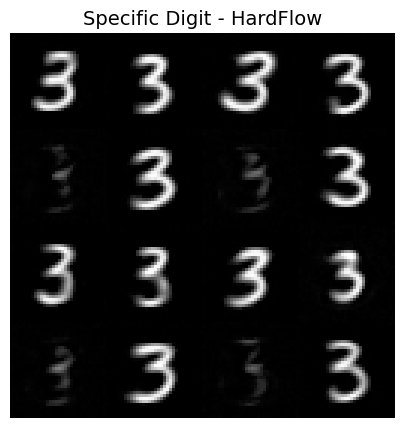

In [ ]:
show_mnist_grid(sampled_data_hf, "Specific Digit - HardFlow")

In [ ]:
sampled_data_hf_list = []
for digit in range(10):
    mean_vec = mean_vec_list[digit]
    basis_vectors = basis_vectors_list[digit]

    sampled_data_hf, _ = sample_mnist_hardflow(model, n_samples=10, loss_fn=lambda x: pca_subspace_loss(x, mean_vec, basis_vectors), guidance_scale=10.0)
    sampled_data_hf_list.append(sampled_data_hf)

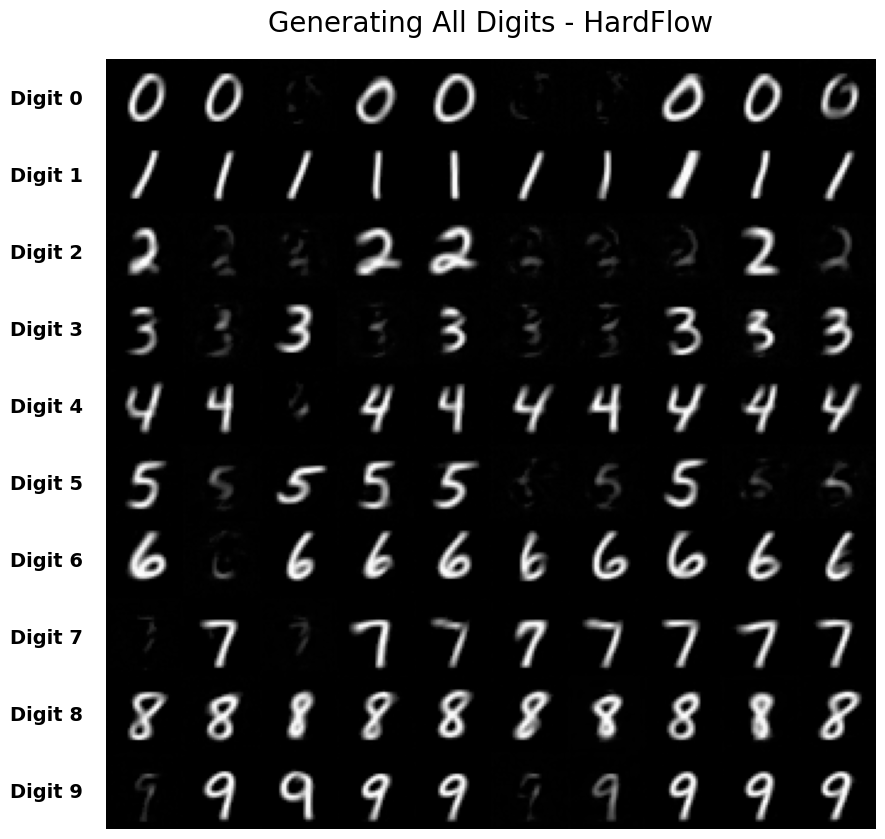

In [ ]:
show_all_digits_grid(sampled_data_hf_list, "Generating All Digits - HardFlow")